# **Exploratory Data Analysis and Visualization: Diamond Dataset**

### This notebook applies:

1. Histograms, density plots and box plots for one numerical variable
2. Bar charts for one categorical variable, drawn in the correct order
3. Scatter plots, grouped box plots, violin plots, stacked bar charts and heatmaps for two variables
4. A correlation heatmap and a pair plot for several variables at once

Dataset: `Diamond.csv` (Chu, 2001) - 308 observations, 5 variables. The same file as in seminar 2.
Source of the data: https://jse.amstat.org/v9n2/datasets.chu.html

Seminar 2 described the data with numbers. This notebook draws the same data, and several
numbers from seminar 2 reappear here as shapes on a chart.

## **1. Import Libraries and Load Data**

In [1]:
# 1.1 Import libraries and load the dataset
# pandas holds the table, matplotlib draws the figure, seaborn adds ready-made statistical charts.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Diamond.csv")

print("Dataset shape:", df.shape)
df.head()

# Interpretation:
# 308 diamonds and 5 columns: carat, colour, clarity, certification, price.
# The file must sit in the same folder as this notebook, otherwise read_csv cannot find it.

Dataset shape: (308, 5)


,carat,colour,clarity,certification,price
0,0.30,D,VS2,GIA,1302
1,0.30,E,VS1,GIA,1510
2,0.30,G,VVS1,GIA,1510
3,0.30,G,VS1,GIA,1260
4,0.31,D,VS1,GIA,1641


In [2]:
# 1.2 Fix the order of the ordered categories
# colour and clarity are ordered scales: D is the best colour and I the worst,
# IF is the best clarity and VS2 the worst. pandas and seaborn do not know this.
# We write the correct order down once and reuse it in every chart below.

colour_order = ["D", "E", "F", "G", "H", "I"]          # best to worst
clarity_order = ["IF", "VVS1", "VVS2", "VS1", "VS2"]   # best to worst

print("Order pandas would use for colour:", list(df["colour"].value_counts().index))
print("Order we want:                    ", colour_order)

# Interpretation:
# Without our list, a bar chart puts the most frequent category first: F, G, H, E, I, D.
# The quality scale is then scrambled and the chart cannot be read from best to worst.
# certification (GIA, HRD, IGI) is not an ordered scale, so it needs no list.

Order pandas would use for colour: ['F', 'G', 'H', 'E', 'I', 'D']
Order we want:                     ['D', 'E', 'F', 'G', 'H', 'I']


## **2. Univariate Analysis: One Variable at a Time**

### 2.1 Numerical variables `carat` and `price`: histogram and density plot

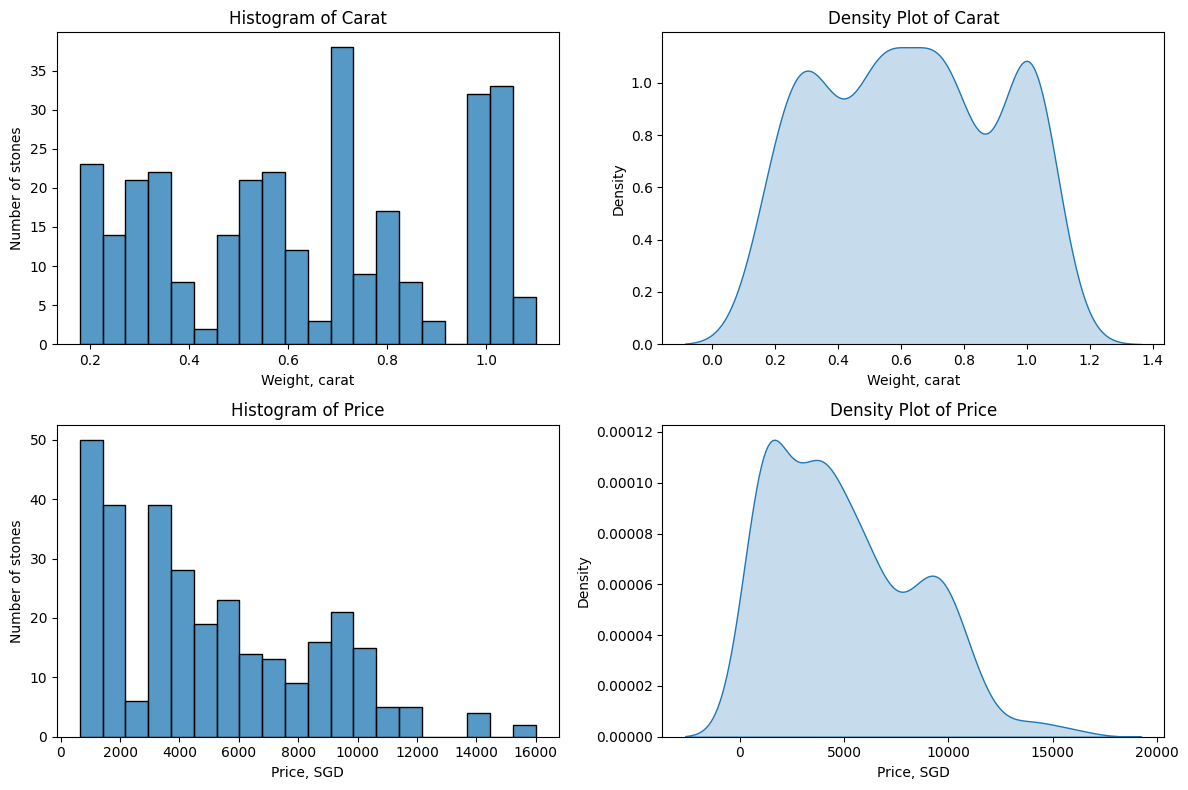

In [3]:
# 2.1 Histogram and density plot of carat and price, on a 2 x 2 grid of panels
# plt.subplots(2, 2) creates four empty panels; axes[row, column] picks one of them.

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["carat"], bins=20, ax=axes[0, 0])
axes[0, 0].set_title("Histogram of Carat")
axes[0, 0].set_xlabel("Weight, carat")
axes[0, 0].set_ylabel("Number of stones")

sns.kdeplot(df["carat"], fill=True, ax=axes[0, 1])
axes[0, 1].set_title("Density Plot of Carat")
axes[0, 1].set_xlabel("Weight, carat")

sns.histplot(df["price"], bins=20, ax=axes[1, 0])
axes[1, 0].set_title("Histogram of Price")
axes[1, 0].set_xlabel("Price, SGD")
axes[1, 0].set_ylabel("Number of stones")

sns.kdeplot(df["price"], fill=True, ax=axes[1, 1])
axes[1, 1].set_title("Density Plot of Price")
axes[1, 1].set_xlabel("Price, SGD")

plt.tight_layout()
plt.show()

# Interpretation:
# A histogram cuts the range of values into 20 intervals (bins) and shows how many stones
# fall into each one. A density plot is the same picture drawn as a smooth outline.
# Price has a long tail to the right: many cheap stones and a few very expensive ones.
# This is what the skewness of 0.66 from seminar 2 looks like.
# Carat has no such tail (skewness 0.01), but it has sharp peaks at 0.5, 0.7 and 1.0 carat:
# the trade prefers round weights, so many stones are cut to exactly those sizes.
# The density outline of price slightly crosses zero on the left. This is a side effect of
# the smoothing, not data: no stone has a negative price.

### 2.2 Numerical variables: box plot

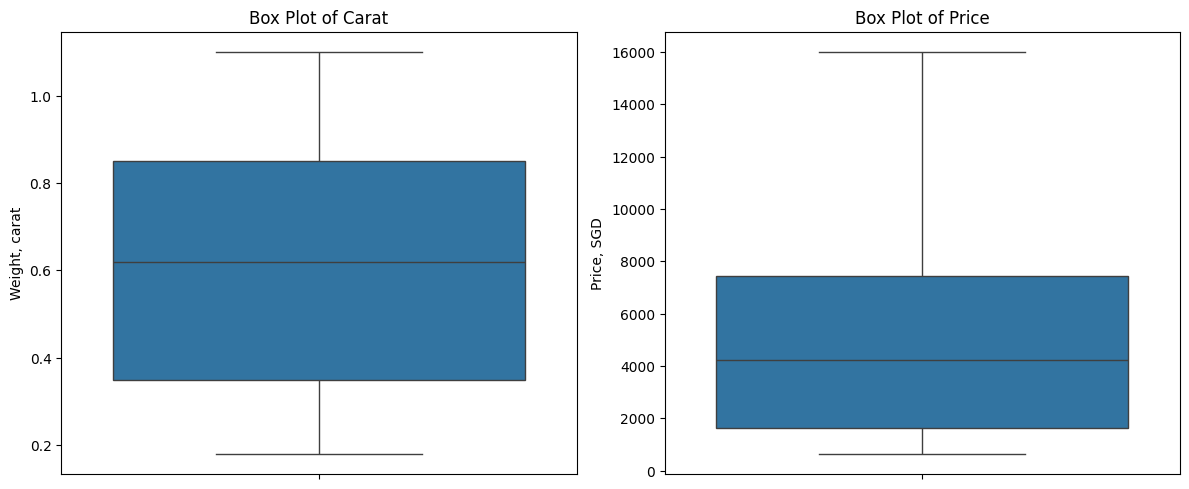

In [4]:
# 2.2 Box plots of carat and price, side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["carat"], ax=axes[0])
axes[0].set_title("Box Plot of Carat")
axes[0].set_ylabel("Weight, carat")

sns.boxplot(y=df["price"], ax=axes[1])
axes[1].set_title("Box Plot of Price")
axes[1].set_ylabel("Price, SGD")

plt.tight_layout()
plt.show()

# Interpretation:
# How to read a box plot:
#   - the line inside the box is the median;
#   - the box runs from Q1 to Q3, so it holds the middle half of the stones (the IQR);
#   - the whiskers reach the most extreme stone that still lies within 1.5 x IQR of the box;
#   - any stone beyond that is drawn as a separate dot: an outlier by the rule from seminar 2.
# Here there are no dots. Seminar 2 found the same with numbers: the upper bound for price
# is 16177.50 and the most expensive stone costs 16008. Because nothing lies beyond the bounds,
# in this dataset the whiskers happen to end at the minimum and the maximum.
# The price box sits low with a long upper whisker: the right tail seen in the histogram.

### 2.3 Categorical variables: bar chart in the correct order

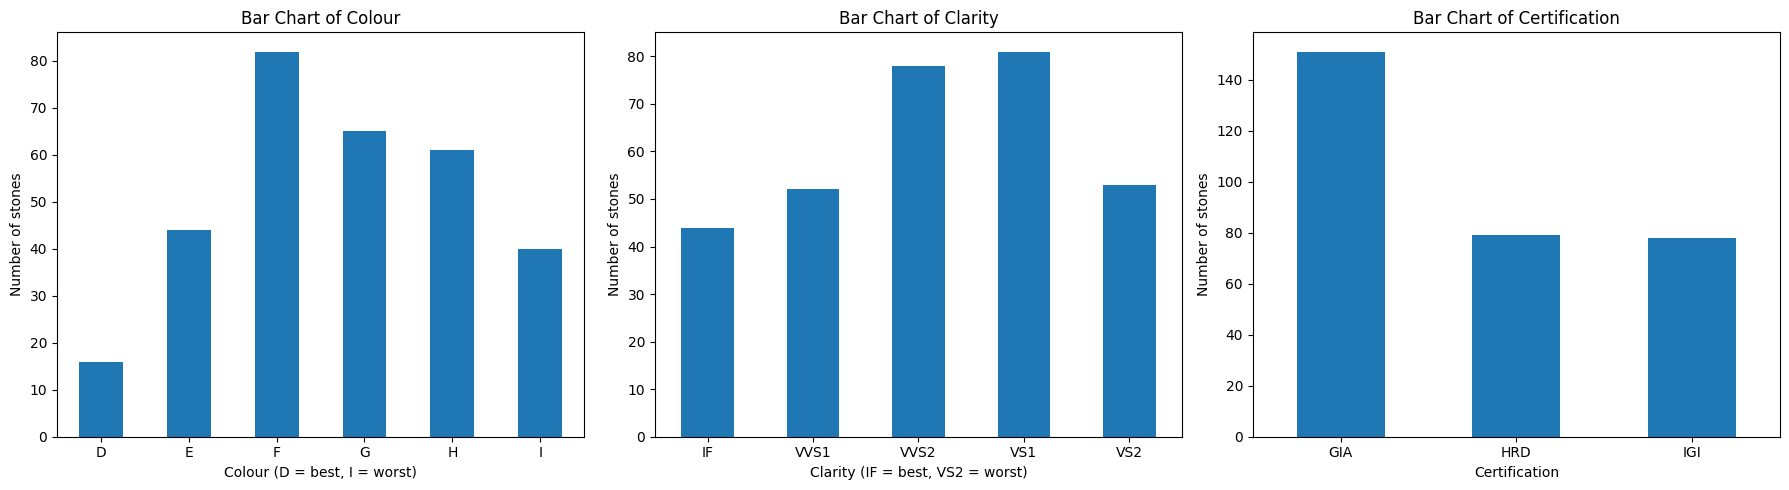

In [5]:
# 2.3 Bar charts of colour, clarity and certification
# .reindex(colour_order) puts the bars in the order of our list instead of by frequency.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["colour"].value_counts().reindex(colour_order).plot(kind="bar", ax=axes[0])
axes[0].set_title("Bar Chart of Colour")
axes[0].set_xlabel("Colour (D = best, I = worst)")
axes[0].set_ylabel("Number of stones")
axes[0].tick_params(axis="x", rotation=0)

df["clarity"].value_counts().reindex(clarity_order).plot(kind="bar", ax=axes[1])
axes[1].set_title("Bar Chart of Clarity")
axes[1].set_xlabel("Clarity (IF = best, VS2 = worst)")
axes[1].set_ylabel("Number of stones")
axes[1].tick_params(axis="x", rotation=0)

df["certification"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Bar Chart of Certification")
axes[2].set_xlabel("Certification")
axes[2].set_ylabel("Number of stones")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Interpretation:
# Colour: F is the most common grade (82 stones) and D, the best, the rarest (16).
# Clarity: VS1 (81) and VVS2 (78) dominate.
# Certification: GIA certifies about half of all stones (151 of 308).
# These are the frequency tables of seminar 2 drawn as bars.

## **3. Bivariate Analysis: Two Variables Together**

### 3.1 Numerical against numerical: scatter plot

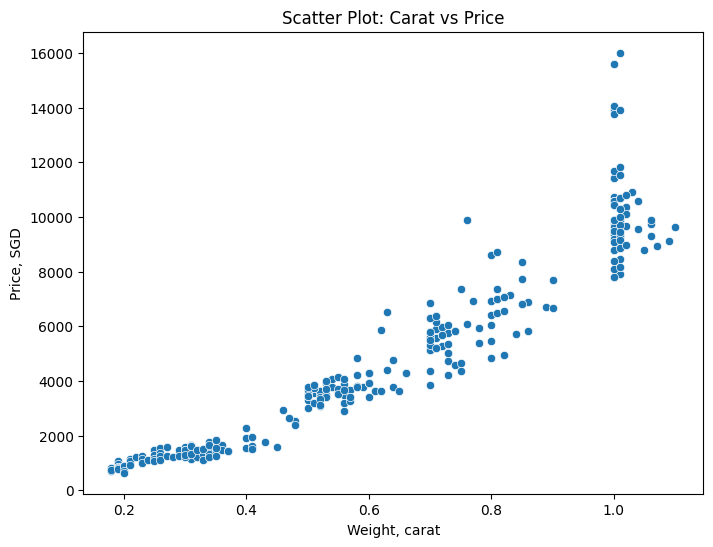

In [6]:
# 3.1 Scatter plot of carat against price
# Each dot is one diamond: its weight on the horizontal axis, its price on the vertical axis.

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="carat", y="price")
plt.title("Scatter Plot: Carat vs Price")
plt.xlabel("Weight, carat")
plt.ylabel("Price, SGD")
plt.show()

# Interpretation:
# The dots rise from bottom left to top right: heavier stones cost more.
# The cloud is narrow, which matches the correlation of 0.94 from seminar 2.
# The vertical stripes at 0.5, 0.7 and 1.0 carat are the round weights seen in the histogram.
# The cloud widens to the right: among heavy stones, price varies much more.

### 3.2 Categorical against numerical: box plots by group

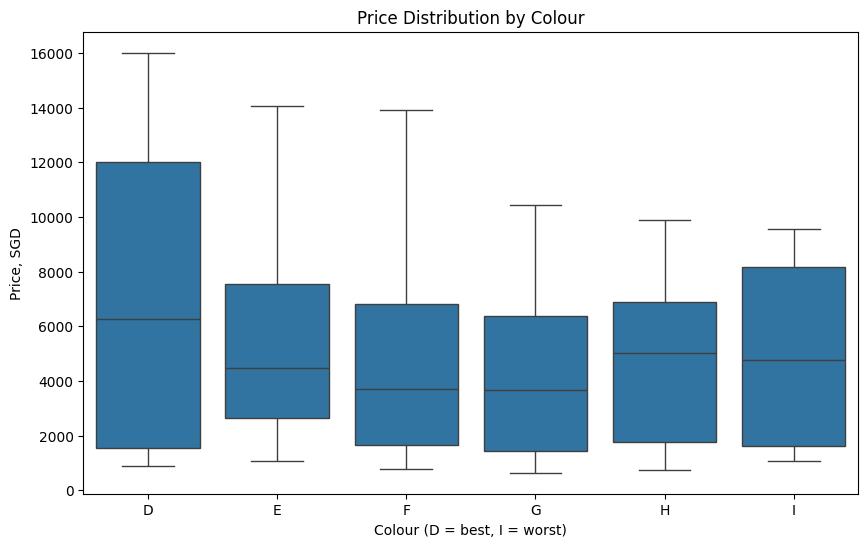

In [7]:
# 3.2 Price by colour, one box per colour, in the order of colour_order

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="colour", y="price", order=colour_order)
plt.title("Price Distribution by Colour")
plt.xlabel("Colour (D = best, I = worst)")
plt.ylabel("Price, SGD")
plt.show()

# Interpretation:
# The median price does not fall steadily from D to I: D 6266, E 4484, F 3714, G 3651,
# then H 5030 and I 4780. The worst colours are not the cheapest.
# Seminar 2 found the same with group means. The reason is weight: the median H and I stones
# weigh 0.71 and 0.78 carat, the median F and G stones only 0.55 and 0.57.
# This pattern is visible only because the boxes stand in the correct order.

### 3.3 Categorical against numerical: violin plot

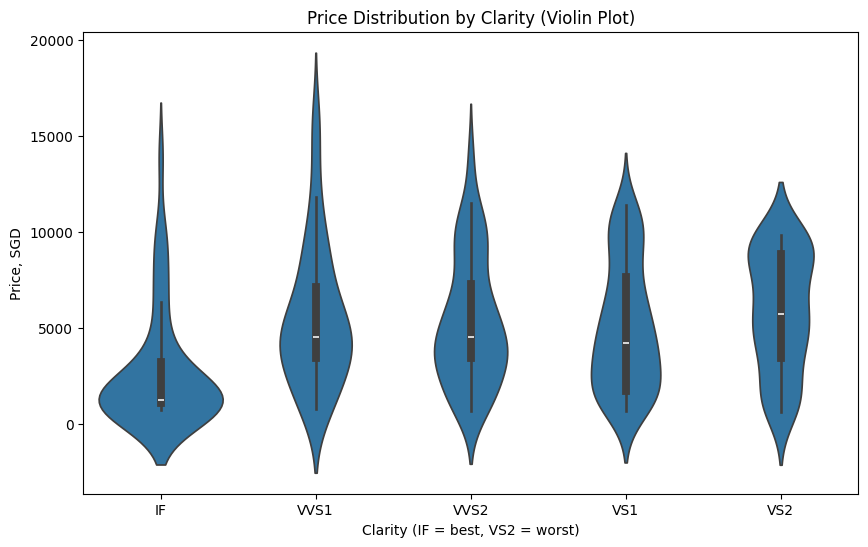

In [8]:
# 3.3 Price by clarity as violins, in the order of clarity_order
# A violin is a box plot with the density outline drawn on both sides.

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="clarity", y="price", order=clarity_order)
plt.title("Price Distribution by Clarity (Violin Plot)")
plt.xlabel("Clarity (IF = best, VS2 = worst)")
plt.ylabel("Price, SGD")
plt.show()

# Interpretation:
# The widest part of each violin shows where most stones of that clarity are priced.
# A surprise: the best clarity, IF, is the cheapest group (median 1266 SGD), and the worst
# clarity, VS2, the most expensive (median 5738 SGD).
# Again the reason is weight: the median IF stone weighs 0.27 carat, the median VS2 stone 0.82.
# A chart shows what is in the data, not the effect of one feature taken alone.
# The tails below zero are again a side effect of the smoothing: no stone has a negative price.

### 3.4 Categorical against categorical: stacked bar chart

clarity        IF  VVS1  VVS2  VS1  VS2
certification                          
GIA             6    15    33   61   36
HRD             4    23    24   13   15
IGI            34    14    21    7    2


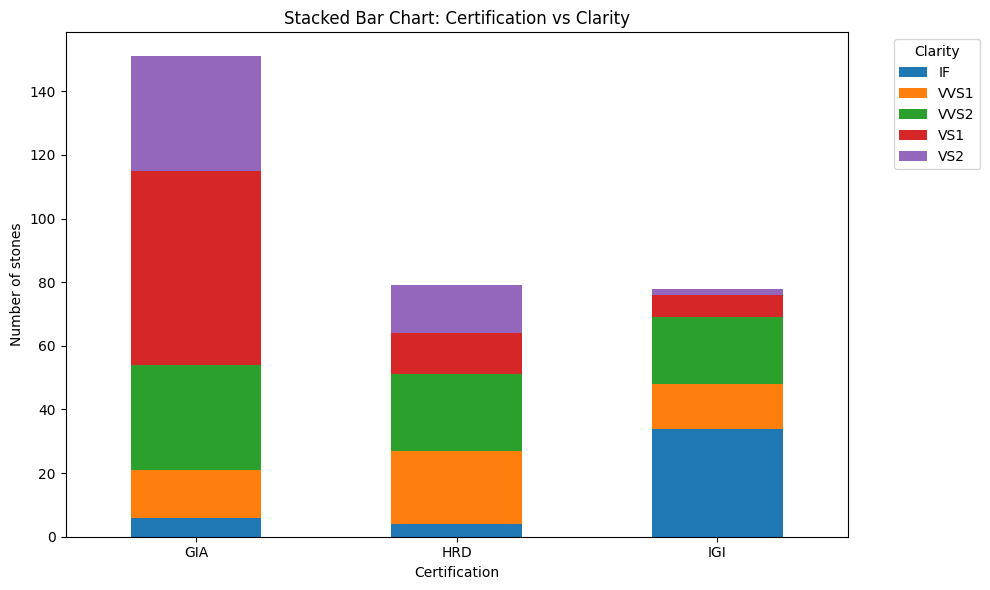

In [9]:
# 3.4 Certification against clarity as a stacked bar chart
# pd.crosstab counts the stones in every pair of categories;
# [clarity_order] puts the clarity columns in our order instead of alphabetical order.

cert_clarity = pd.crosstab(df["certification"], df["clarity"])[clarity_order]
print(cert_clarity)

cert_clarity.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Stacked Bar Chart: Certification vs Clarity")
plt.xlabel("Certification")
plt.ylabel("Number of stones")
plt.xticks(rotation=0)
plt.legend(title="Clarity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Interpretation:
# Each bar is one laboratory; its coloured pieces are the clarity grades of its stones.
# The laboratories certify very different stones: 34 of IGI's 78 stones are IF,
# while GIA's largest group is VS1 (61 of 151).

### 3.5 Categorical against categorical: heatmap of the same table

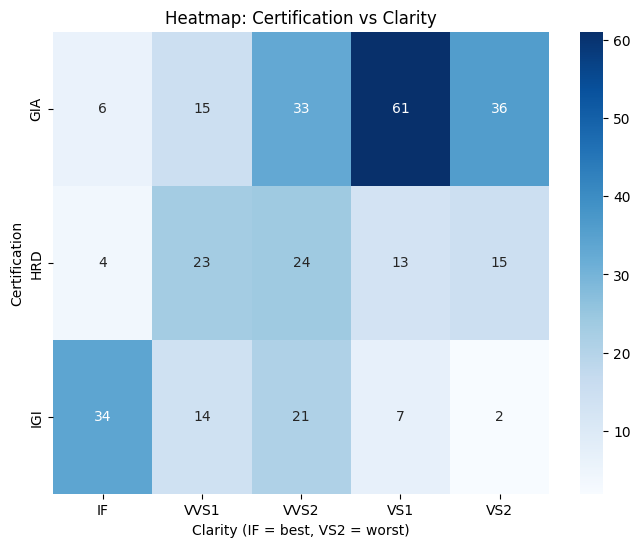

In [10]:
# 3.5 The same contingency table drawn as a heatmap
# annot=True writes the counts in the cells; fmt="d" prints them as whole numbers.

plt.figure(figsize=(8, 6))
sns.heatmap(cert_clarity, annot=True, fmt="d", cmap="Blues")
plt.title("Heatmap: Certification vs Clarity")
plt.xlabel("Clarity (IF = best, VS2 = worst)")
plt.ylabel("Certification")
plt.show()

# Interpretation:
# The darker the cell, the more stones. The two darkest cells are GIA-VS1 (61) and IGI-IF (34).
# A heatmap shows the same numbers as the table, but the eye finds the large ones at once.

## **4. Multivariate Analysis: Several Variables at Once**

### 4.1 A third numerical variable: price per carat

In [11]:
# 4.1 Create a new column: the price of one carat of each stone
# The dataset has only two numerical columns. A third one makes the charts below meaningful.

df["price_per_carat"] = df["price"] / df["carat"]
print(df[["carat", "price", "price_per_carat"]].describe().round(2))

# Interpretation:
# A typical stone costs about 6992 SGD per carat (the median).
# The cheapest carat costs 3190 SGD, the most expensive 15850 SGD.

        carat     price  price_per_carat
count  308.00    308.00           308.00
mean     0.63   5019.48          7104.61
std      0.28   3403.12          2293.75
min      0.18    638.00          3190.00
25%      0.35   1625.00          5193.21
50%      0.62   4215.00          6992.25
75%      0.85   7446.00          8628.18
max      1.10  16008.00         15849.50


### 4.2 Correlation heatmap (lecture slides 26, 49-50)

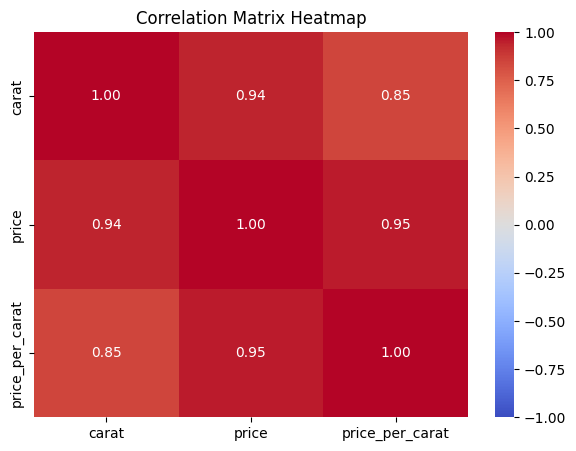

In [12]:
# 4.2 Correlation matrix of the three numerical columns, drawn as a heatmap
# vmin=-1 and vmax=1 fix the colour scale to the full range of a correlation.

num_df = df[["carat", "price", "price_per_carat"]]
corr_matrix = num_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

# Interpretation:
# Red means a strong positive correlation, blue a negative one, white none.
# carat and price: 0.94. carat and price per carat: 0.85.
# The second number is the interesting one: heavier stones cost more not only in total
# but also for every carat. The price of a diamond grows faster than its weight.

### 4.3 Pair plot

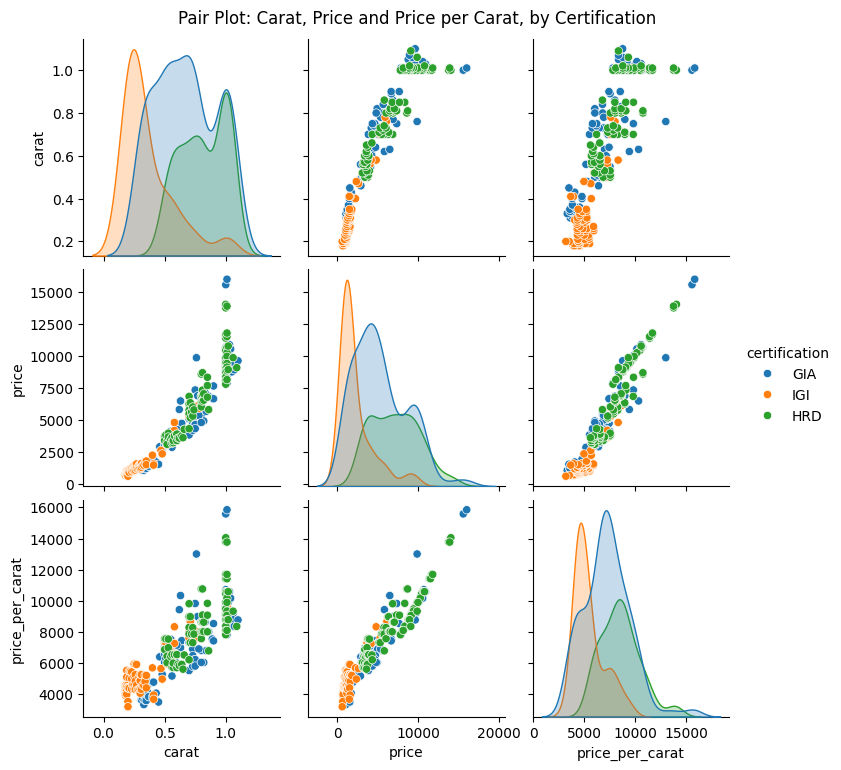

In [13]:
# 4.3 Pair plot of the three numerical columns, coloured by certification
# Every pair of columns gets its own scatter plot; the diagonal shows each column alone.

sns.pairplot(df, vars=["carat", "price", "price_per_carat"], hue="certification")
plt.suptitle("Pair Plot: Carat, Price and Price per Carat, by Certification", y=1.02)
plt.show()

# Interpretation:
# One picture holds three scatter plots and three density plots.
# The orange IGI dots gather in the lower left of the scatter panels: small, cheap, and cheap per carat.
# The HRD stones sit higher: heavier and more expensive.
# The colour of the dots adds a fourth variable, certification, to the picture.

## **5. Summary**

- Ordered categories must be put in order by hand: `.reindex(order)` for bar charts, `order=` for seaborn charts, `[order]` for the columns of a crosstab. Without it the scale is scrambled.
- The histogram of price shows the long right tail that seminar 2 measured as a skewness of 0.66.
- The box plots show no dots beyond the whiskers, the same conclusion as the 1.5 x IQR rule in seminar 2.
- Heavier stones cost more, and the scatter plot shows a narrow rising cloud (correlation 0.94).
- The worst colours and the best clarity are not where one would expect on the price axis, because the groups differ in weight. A chart shows what is in the data, not the effect of one feature alone.
- The laboratories certify very different stones: IGI mostly small IF stones, GIA mostly VS1.
- Price grows faster than weight: price per carat rises with carat (correlation 0.85).